### 첫 투표 이전 구간 분석 EDA

#### 분석 데이터 준비

##### 라이브러리 및 파일 경로

In [5]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

base_path = Path(
    r"C:\DA15_Part4\sns-project\team4-final-project\data\processed"
)

# 한글 폰트
available_fonts = {
    font.name for font in font_manager.fontManager.ttflist
}

for font in ["Malgun Gothic", "AppleGothic", "NanumGothic"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams["axes.unicode_minus"] = False

##### 사용자 및 투표 기록 불러오기

In [6]:
df_user = pd.read_csv(
    base_path / "accounts_user_preprocessed_2.csv",
    usecols=["id", "created_at", "group_id"]
)

df_vote = pd.read_csv(
    base_path / "accounts_userquestionrecord_preprocessed_2.csv",
    usecols=["user_id", "chosen_user_id", "created_at"]
)

# 날짜형 변환
df_user["created_at"] = pd.to_datetime(
    df_user["created_at"], errors="coerce"
)

df_vote["created_at"] = pd.to_datetime(
    df_vote["created_at"], errors="coerce"
)

# ID 형식 통일
df_user["id"] = pd.to_numeric(
    df_user["id"], errors="coerce"
).astype("Int64")

for col in ["user_id", "chosen_user_id"]:
    df_vote[col] = pd.to_numeric(
        df_vote[col], errors="coerce"
    ).astype("Int64")

df_user = df_user.dropna(subset=["id", "created_at"]).copy()

df_vote = df_vote.dropna(
    subset=["created_at", "chosen_user_id"]
).copy()

print(f"전체 사용자: {df_user['id'].nunique():,}명")
print(
    "투표 기록 기간:",
    df_vote["created_at"].min(),
    "~",
    df_vote["created_at"].max()
)

전체 사용자: 677,075명
투표 기록 기간: 2023-05-13 00:00:02 ~ 2024-05-07 11:29:07


#### 사용자별 첫 친구 관계 기록 시각 계산

##### 첫 A상태 친구 요청 기록 시각 추출

In [7]:
friend_path = (
    base_path / "accounts_friendrequest_preprocessed_2.csv"
)

friend_min = None

for chunk in pd.read_csv(
    friend_path,
    usecols=[
        "status",
        "send_user_id",
        "receive_user_id",
        "created_at",
        "updated_at"
    ],
    chunksize=300_000
):
    # 현재 A 상태인 친구 요청만 사용
    accepted = chunk.loc[
        chunk["status"].eq("A")
    ].copy()

    if accepted.empty:
        continue

    accepted["created_at"] = pd.to_datetime(
        accepted["created_at"], errors="coerce"
    )

    accepted["updated_at"] = pd.to_datetime(
        accepted["updated_at"], errors="coerce"
    )

    # 발신자와 수신자 모두 친구 관계 경험자로 집계
    sender = accepted[
        ["send_user_id", "created_at", "updated_at"]
    ].rename(columns={"send_user_id": "user_id"})

    receiver = accepted[
        ["receive_user_id", "created_at", "updated_at"]
    ].rename(columns={"receive_user_id": "user_id"})

    both = pd.concat(
        [sender, receiver],
        ignore_index=True
    )

    both = both.dropna(subset=["user_id"])

    # 청크별 사용자 최초 기록
    local_min = both.groupby("user_id").agg(
        first_A_created_at=("created_at", "min"),
        first_A_updated_at=("updated_at", "min")
    )

    # 전체 청크의 최초 기록과 합치기
    if friend_min is None:
        friend_min = local_min
    else:
        friend_min = (
            pd.concat([friend_min, local_min])
            .groupby(level=0)
            .min()
        )

df_first_friend = (
    friend_min
    .reset_index()
    .rename(columns={"user_id": "id"})
)

df_first_friend["id"] = (
    pd.to_numeric(df_first_friend["id"], errors="coerce")
    .astype("Int64")
)

display(df_first_friend.head())

print(
    "친구 관계 기록 사용자:",
    f"{df_first_friend['id'].nunique():,}명"
)

,id,first_A_created_at,first_A_updated_at
0,831962,2023-07-13 07:51:59,2023-09-11 15:38:43
1,833024,2023-05-13 00:48:28,2023-05-18 03:54:24
2,833041,2023-05-13 21:23:59,2023-05-14 00:29:43
3,833112,2023-06-01 12:34:24,2023-09-17 20:23:41
4,833202,2023-05-14 15:15:37,2023-05-15 12:52:33


친구 관계 기록 사용자: 574,163명


#### 첫 친구 관계 기록 이후 첫 수신까지의 대기 시간

##### 사용자별 첫 수신 기록 시각 계산

In [8]:
df_first_receive = (
    df_vote
    .groupby("chosen_user_id", as_index=False)["created_at"]
    .min()
    .rename(columns={
        "chosen_user_id": "id",
        "created_at": "first_receive_at"
    })
)

df_first_receive["id"] = (
    df_first_receive["id"].astype("Int64")
)

display(df_first_receive.head())

,id,first_receive_at
0,833113,2023-05-14 15:22:20
1,833203,2023-05-14 12:23:14
2,833294,2023-05-17 12:41:58
3,833525,2023-05-14 05:44:02
4,833573,2023-05-16 05:51:34


##### 두 시각 결합 및 시간 순서 확인

In [9]:
df_timing = (
    df_first_friend
    .merge(
        df_user[["id", "created_at", "group_id"]].rename(
            columns={"created_at": "registered_at"}
        ),
        on="id",
        how="inner"
    )
    .merge(
        df_first_receive,
        on="id",
        how="left"
    )
)

# 기준 시각: 첫 A상태 친구 요청의 갱신 시각
df_timing["baseline_at"] = df_timing["first_A_updated_at"]

df_timing = df_timing.dropna(
    subset=["baseline_at"]
).copy()

# 기록상 친구 관계 기준 시각보다 먼저 투표를 받은 경우
df_timing["receive_before_baseline"] = (
    df_timing["first_receive_at"]
    < df_timing["baseline_at"]
)

# 두 시각이 동일한 경우: 선후 관계 불명확
df_timing["receive_same_time"] = (
    df_timing["first_receive_at"]
    == df_timing["baseline_at"]
)

print(
    "기준 시각보다 먼저 수신 기록이 있는 사용자:",
    f"{df_timing['receive_before_baseline'].sum():,}명"
)

print(
    "두 시각이 동일한 사용자:",
    f"{df_timing['receive_same_time'].sum():,}명"
)

display(
    df_timing[
        [
            "id",
            "registered_at",
            "first_A_created_at",
            "baseline_at",
            "first_receive_at",
            "receive_before_baseline"
        ]
    ].head()
)

기준 시각보다 먼저 수신 기록이 있는 사용자: 4,039명
두 시각이 동일한 사용자: 0명


,id,registered_at,first_A_created_at,baseline_at,first_receive_at,receive_before_baseline
0,831962,2023-03-29 05:18:56.162368,2023-07-13 07:51:59,2023-09-11 15:38:43,NaT,False
1,833024,2023-03-31 09:05:51.903699,2023-05-13 00:48:28,2023-05-18 03:54:24,NaT,False
2,833041,2023-03-31 14:32:36.425315,2023-05-13 21:23:59,2023-05-14 00:29:43,NaT,False
3,833112,2023-03-31 15:55:48.870381,2023-06-01 12:34:24,2023-09-17 20:23:41,NaT,False
4,833202,2023-03-31 15:58:12.136011,2023-05-14 15:15:37,2023-05-15 12:52:33,NaT,False


#### 동일한 관측 기간에서 7일 내 첫 수신 기록 확인

##### 분석 대상 생성

In [10]:
vote_start = df_vote["created_at"].min()
vote_end = df_vote["created_at"].max()

# 투표 기록 시작 후 7일이 지난 시점부터 관측
cohort_start = max(
    vote_start + pd.Timedelta(days=7),
    pd.Timestamp("2023-05-20")
)

# 2023년 6월 내에서 7일 관측 기간이 확보되는 시점까지
cohort_end = min(
    pd.Timestamp("2023-06-23 23:59:59"),
    vote_end - pd.Timedelta(days=7)
)

df_cohort = df_timing.loc[
    df_timing["baseline_at"].between(
        cohort_start, cohort_end
    )
    & (
        df_timing["registered_at"]
        <= df_timing["baseline_at"]
    )
].copy()

# 기준 시점 이전에 이미 수신 기록이 있는 사람은 별도 집계
prior_receive_count = (
    df_cohort["first_receive_at"]
    <= df_cohort["baseline_at"]
).sum()

# 첫 수신이 기준 시점 이후이거나 수신 기록이 없는 사용자
df_wait = df_cohort.loc[
    df_cohort["first_receive_at"].isna()
    | (
        df_cohort["first_receive_at"]
        > df_cohort["baseline_at"]
    )
].copy()

# 첫 수신 기록까지 걸린 시간
df_wait["wait_days"] = (
    df_wait["first_receive_at"]
    - df_wait["baseline_at"]
).dt.total_seconds() / 86400

# 기준 시점 이후 7일 내 수신 기록 존재 여부
df_wait["received_7d"] = (
    df_wait["wait_days"].ge(0)
    & df_wait["wait_days"].le(7)
)

print("분석 기준 기간:", cohort_start, "~", cohort_end)
print(f"기간 내 기준 사용자: {len(df_cohort):,}명")
print(f"기준 시점 이전 수신 기록자: {prior_receive_count:,}명")
print(f"첫 수신 대기 분석 대상: {len(df_wait):,}명")

if len(df_wait) > 0:
    print(
        "7일 내 첫 수신 기록 비율:",
        f"{df_wait['received_7d'].mean() * 100:.1f}%"
    )

분석 기준 기간: 2023-05-20 00:00:02 ~ 2023-06-23 23:59:59
기간 내 기준 사용자: 210,535명
기준 시점 이전 수신 기록자: 1,256명
첫 수신 대기 분석 대상: 209,279명
7일 내 첫 수신 기록 비율: 1.0%


#### 첫 수신까지 걸린 시간 분포

##### 대기 시간 구간별 사용자 수·비율 계산

In [11]:
if df_wait.empty:
    raise ValueError("분석 대상이 없습니다. cohort_start/end를 확인하세요.")

conditions = [
    df_wait["wait_days"].between(0, 1, inclusive="both"),
    df_wait["wait_days"].gt(1) & df_wait["wait_days"].le(3),
    df_wait["wait_days"].gt(3) & df_wait["wait_days"].le(7)
]

labels = [
    "1일 이내",
    "1일 초과~3일 이내",
    "3일 초과~7일 이내"
]

df_wait["수신 시점"] = np.select(
    conditions,
    labels,
    default="7일 내 수신 기록 없음"
)

order = [
    "1일 이내",
    "1일 초과~3일 이내",
    "3일 초과~7일 이내",
    "7일 내 수신 기록 없음"
]

df_wait_summary = (
    df_wait["수신 시점"]
    .value_counts()
    .reindex(order, fill_value=0)
    .rename_axis("수신 시점")
    .reset_index(name="사용자 수")
)

df_wait_summary["비율"] = (
    df_wait_summary["사용자 수"]
    / len(df_wait)
    * 100
).round(1)

display(df_wait_summary)

# 실제로 7일 이내 첫 수신 기록이 있는 사용자만의 대기 시간
wait_7d = df_wait.loc[
    df_wait["received_7d"], "wait_days"
]

if not wait_7d.empty:
    print(
        "7일 내 수신 기록자의 대기 시간 중앙값:",
        f"{wait_7d.median():.2f}일"
    )

,수신 시점,사용자 수,비율
0,1일 이내,1249,0.6
1,1일 초과~3일 이내,495,0.2
2,3일 초과~7일 이내,368,0.2
3,7일 내 수신 기록 없음,207167,99.0


7일 내 수신 기록자의 대기 시간 중앙값: 0.64일


##### 가로 막대그래프 시각화

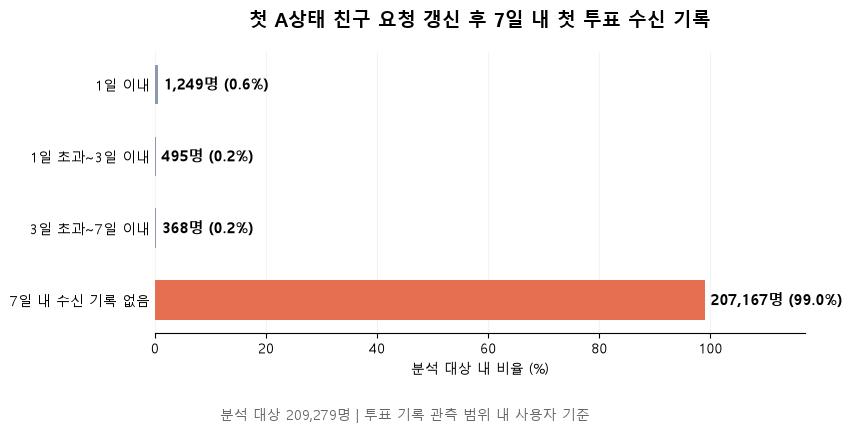

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.6))

colors = [
    "#8D99AE",
    "#8D99AE",
    "#8D99AE",
    "#E76F51"
]

bars = ax.barh(
    df_wait_summary["수신 시점"],
    df_wait_summary["비율"],
    color=colors,
    height=0.55
)

for bar, count, rate in zip(
    bars,
    df_wait_summary["사용자 수"],
    df_wait_summary["비율"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}명 ({rate:.1f}%)",
        va="center",
        ha="left",
        fontsize=11,
        fontweight="bold"
    )

ax.invert_yaxis()

ax.set_xlim(
    0,
    max(100, df_wait_summary["비율"].max() + 18)
)

ax.set_xlabel("분석 대상 내 비율 (%)")

ax.set_title(
    "첫 A상태 친구 요청 갱신 후 7일 내 첫 투표 수신 기록",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)

ax.grid(axis="x", alpha=0.15)
ax.set_axisbelow(True)

fig.text(
    0.5, 0.03,
    f"분석 대상 {len(df_wait):,}명 | "
    "투표 기록 관측 범위 내 사용자 기준",
    ha="center",
    fontsize=10,
    color="#666666"
)

plt.subplots_adjust(
    left=0.25,
    right=0.9,
    top=0.83,
    bottom=0.22
)

plt.show()

#### 기록 시기에 따라 결과가 달라지는지 확인

##### 기준 월별 7일 내 첫 수신 기록 비율

In [13]:
df_wait["기준 월"] = (
    df_wait["baseline_at"]
    .dt.to_period("M")
    .astype(str)
)

df_month = (
    df_wait
    .groupby("기준 월")
    .agg(
        분석_대상=("id", "nunique"),
        수신_기록자=("received_7d", "sum")
    )
    .reset_index()
)

df_month["7일 내 수신 기록 비율"] = (
    df_month["수신_기록자"]
    / df_month["분석_대상"]
    * 100
).round(1)

display(df_month)

,기준 월,분석_대상,수신_기록자,7일 내 수신 기록 비율
0,2023-05,186549,2060,1.1
1,2023-06,22730,52,0.2


---

##### 분석 기간 통일

In [17]:
# 분석 기간: 투표 기록이 집중된 2023년 5~6월
period_start = pd.Timestamp("2023-05-01")
period_end = pd.Timestamp("2023-07-01")   # 7/1 미만 = 6/30까지

df_vote_period = df_vote.loc[
    (df_vote["created_at"] >= period_start)
    & (df_vote["created_at"] < period_end)
].copy()

print(
    "분석 기간:",
    period_start.date(),
    "~",
    (period_end - pd.Timedelta(days=1)).date()
)

print(f"투표 기록 수: {len(df_vote_period):,}건")
print(
    "투표 수신 기록 사용자:",
    f"{df_vote_period['chosen_user_id'].nunique():,}명"
)
print(
    "투표 참여 기록 사용자:",
    f"{df_vote_period['user_id'].nunique():,}명"
)

분석 기간: 2023-05-01 ~ 2023-06-30
투표 기록 수: 790,059건
투표 수신 기록 사용자: 13,617명
투표 참여 기록 사용자: 4,270명


##### 사용자별 투표 수신량과 투표 참여 사용자 생성

In [18]:
# 사용자별 투표 수신 건수
df_receive_cnt = (
    df_vote_period
    .groupby("chosen_user_id")
    .size()
    .rename("receive_cnt")
    .reset_index()
    .rename(columns={"chosen_user_id": "user_id"})
)

# 투표에 한 번이라도 참여한 사용자
active_voter_set = set(
    df_vote_period["user_id"]
    .dropna()
    .astype("int64")
    .unique()
)

# 분석 대상 = 실제 수신 기록이 존재하는 사용자
target_ids = set(
    df_receive_cnt["user_id"]
    .dropna()
    .astype("int64")
)

print(f"수신 분석 대상: {len(target_ids):,}명")
print(f"투표 참여 사용자: {len(active_voter_set):,}명")

display(df_receive_cnt.head())

수신 분석 대상: 13,617명
투표 참여 사용자: 4,270명


,user_id,receive_cnt
0,833113,3
1,833203,25
2,833294,11
3,833525,10
4,833573,2


##### 수신 사용자들의 친구 관계 추출

In [19]:
friend_parts = []

for chunk in pd.read_csv(
    friend_path,
    usecols=[
        "status",
        "send_user_id",
        "receive_user_id"
    ],
    chunksize=300_000
):
    # 현재 A 상태인 친구 관계
    accepted = chunk.loc[
        chunk["status"].eq("A")
    ].copy()

    if accepted.empty:
        continue

    # ID 숫자형 통일
    accepted["send_user_id"] = pd.to_numeric(
        accepted["send_user_id"],
        errors="coerce"
    )

    accepted["receive_user_id"] = pd.to_numeric(
        accepted["receive_user_id"],
        errors="coerce"
    )

    accepted = accepted.dropna(
        subset=["send_user_id", "receive_user_id"]
    )

    accepted["send_user_id"] = (
        accepted["send_user_id"].astype("int64")
    )

    accepted["receive_user_id"] = (
        accepted["receive_user_id"].astype("int64")
    )

    # 분석 대상 사용자가 포함된 친구 관계만 남김
    accepted = accepted.loc[
        accepted["send_user_id"].isin(target_ids)
        | accepted["receive_user_id"].isin(target_ids)
    ]

    if accepted.empty:
        continue

    # 발신자 기준
    sender = (
        accepted[
            ["send_user_id", "receive_user_id"]
        ]
        .rename(columns={
            "send_user_id": "user_id",
            "receive_user_id": "friend_id"
        })
    )

    # 수신자 기준
    receiver = (
        accepted[
            ["receive_user_id", "send_user_id"]
        ]
        .rename(columns={
            "receive_user_id": "user_id",
            "send_user_id": "friend_id"
        })
    )

    pairs = pd.concat(
        [sender, receiver],
        ignore_index=True
    )

    # 분석 대상 사용자 기준으로만 남김
    pairs = pairs.loc[
        pairs["user_id"].isin(target_ids)
    ]

    friend_parts.append(pairs)

# 전체 친구 관계 합치기
df_friend_pairs = (
    pd.concat(friend_parts, ignore_index=True)
    .drop_duplicates(["user_id", "friend_id"])
)

# 자기 자신 연결 제거
df_friend_pairs = df_friend_pairs.loc[
    df_friend_pairs["user_id"]
    != df_friend_pairs["friend_id"]
].copy()

print(
    "분석 대상의 친구 관계 쌍:",
    f"{len(df_friend_pairs):,}건"
)

display(df_friend_pairs.head())

분석 대상의 친구 관계 쌍: 276,191건


,user_id,friend_id
0,1189890,981284
1,1189890,984540
2,1189890,994573
3,1189890,1037142
4,1189890,1064099


##### 친구 수와 ‘투표 활동 친구 수’ 계산

- 활동 친구 정의 : 2023년 5~6월 동안 user_id로 투표 참여 기록이 한 번이라도 존재하는 친구
- 2023년 5~6월로 기간을 선정한 이유는 `accounts_userquestionrecord` 테이블에서 투표 기록의 98.7%정도가 이 시기에 집중되어있었기 때문에

In [20]:
# 친구가 투표에 참여한 기록이 있는지
df_friend_pairs["active_friend"] = (
    df_friend_pairs["friend_id"]
    .isin(active_voter_set)
)

# 사용자별 친구 특성 집계
df_friend_summary = (
    df_friend_pairs
    .groupby("user_id")
    .agg(
        friend_cnt=("friend_id", "nunique"),
        active_friend_cnt=("active_friend", "sum")
    )
    .reset_index()
)

# 활동 친구 비율
df_friend_summary["active_friend_ratio"] = (
    df_friend_summary["active_friend_cnt"]
    / df_friend_summary["friend_cnt"]
)

# 수신량 결합
df_activity = (
    df_receive_cnt
    .merge(
        df_friend_summary,
        on="user_id",
        how="inner"
    )
)

print(f"최종 분석 대상: {len(df_activity):,}명")

display(
    df_activity[
        [
            "user_id",
            "receive_cnt",
            "friend_cnt",
            "active_friend_cnt",
            "active_friend_ratio"
        ]
    ].head()
)

최종 분석 대상: 10,499명


,user_id,receive_cnt,friend_cnt,active_friend_cnt,active_friend_ratio
0,833203,25,8,0,0.0
1,833294,11,1,0,0.0
2,833525,10,5,1,0.2
3,834485,6,7,0,0.0
4,837530,26,1,0,0.0


##### 기본 분포 확인

In [21]:
summary = pd.DataFrame({
    "지표": [
        "친구 수",
        "활동 친구 수",
        "활동 친구 비율",
        "투표 수신 건수"
    ],
    "평균": [
        df_activity["friend_cnt"].mean(),
        df_activity["active_friend_cnt"].mean(),
        df_activity["active_friend_ratio"].mean(),
        df_activity["receive_cnt"].mean()
    ],
    "중앙값": [
        df_activity["friend_cnt"].median(),
        df_activity["active_friend_cnt"].median(),
        df_activity["active_friend_ratio"].median(),
        df_activity["receive_cnt"].median()
    ]
})

display(summary.round(2))

,지표,평균,중앙값
0,친구 수,26.31,17.00
1,활동 친구 수,9.50,1.00
2,활동 친구 비율,0.33,0.07
3,투표 수신 건수,69.49,11.00


##### 활동 친구 비율별 투표 수신량 비교

In [27]:
# 활동 친구 비율 기준 순위 생성
# 같은 값이 많아도 사용자 순서를 이용해 4개 그룹으로 나눌 수 있음
df_activity["activity_rank"] = (
    df_activity["active_friend_ratio"]
    .rank(method="first")
)

# 사용자 수가 최대한 동일하도록 4등분
df_activity["활동 친구 비율 그룹"] = pd.qcut(
    df_activity["activity_rank"],
    q=4,
    labels=[
        "하위 25%",
        "25~50%",
        "50~75%",
        "상위 25%"
    ]
)

# 그룹별 요약
df_activity_summary = (
    df_activity
    .groupby(
        "활동 친구 비율 그룹",
        observed=True
    )
    .agg(
        사용자_수=("user_id", "nunique"),
        활동친구비율_중앙값=("active_friend_ratio", "median"),
        활동친구비율_평균=("active_friend_ratio", "mean"),
        수신_중앙값=("receive_cnt", "median"),
        수신_평균=("receive_cnt", "mean"),
        친구수_중앙값=("friend_cnt", "median")
    )
    .reset_index()
)

# 비율 → %
df_activity_summary["활동친구비율_중앙값"] = (
    df_activity_summary["활동친구비율_중앙값"] * 100
).round(1)

df_activity_summary["활동친구비율_평균"] = (
    df_activity_summary["활동친구비율_평균"] * 100
).round(1)

df_activity_summary["수신_평균"] = (
    df_activity_summary["수신_평균"].round(1)
)

display(df_activity_summary)

,활동 친구 비율 그룹,사용자_수,활동친구비율_중앙값,활동친구비율_평균,수신_중앙값,수신_평균,친구수_중앙값
0,하위 25%,2625,0.0,0.0,3.0,8.5,4.0
1,25~50%,2625,2.4,2.6,3.0,7.9,38.0
2,50~75%,2624,28.6,34.6,23.0,63.5,14.0
3,상위 25%,2625,96.4,94.5,165.0,198.0,23.0


##### 활동 친구 비율별 수신량 시각화

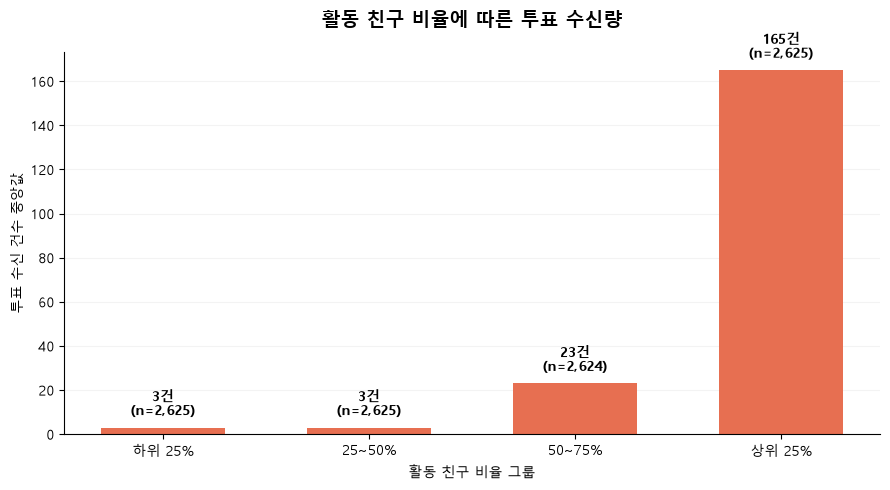

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df_activity_summary["활동 친구 비율 그룹"].astype(str),
    df_activity_summary["수신_중앙값"],
    color="#E76F51",
    width=0.6
)

for bar, value, n in zip(
    bars,
    df_activity_summary["수신_중앙값"],
    df_activity_summary["사용자_수"]
):
    ax.annotate(
        f"{value:.0f}건\n(n={n:,})",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlabel("활동 친구 비율 그룹")
ax.set_ylabel("투표 수신 건수 중앙값")

ax.set_title(
    "활동 친구 비율에 따른 투표 수신량",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### 중요한 검증 — 친구 수를 비슷하게 맞춰서 비교

In [30]:
# 친구 수가 같은 값이 많아도 4등분 가능하도록 순위 생성
df_activity["friend_rank"] = (
    df_activity["friend_cnt"]
    .rank(method="first")
)

# 친구 수 기준 사용자 수가 최대한 동일한 4개 그룹
df_activity["친구 수 그룹"] = pd.qcut(
    df_activity["friend_rank"],
    q=4,
    labels=[
        "하위 25%",
        "25~50%",
        "50~75%",
        "상위 25%"
    ]
)

# 같은 친구 수 그룹 안에서
# 활동 친구 비율을 다시 절반으로 나눔
df_activity["activity_rank_within"] = (
    df_activity
    .groupby("친구 수 그룹", observed=True)["active_friend_ratio"]
    .rank(method="first", pct=True)
)

df_activity["친구 활동성"] = np.where(
    df_activity["activity_rank_within"] <= 0.5,
    "낮음",
    "높음"
)

# 그룹별 결과 요약
df_control_summary = (
    df_activity
    .groupby(
        ["친구 수 그룹", "친구 활동성"],
        observed=True
    )
    .agg(
        사용자_수=("user_id", "nunique"),
        친구수_중앙값=("friend_cnt", "median"),
        활동친구비율_중앙값=("active_friend_ratio", "median"),
        수신_중앙값=("receive_cnt", "median"),
        수신_평균=("receive_cnt", "mean")
    )
    .reset_index()
)

df_control_summary["활동친구비율_중앙값"] = (
    df_control_summary["활동친구비율_중앙값"] * 100
).round(1)

df_control_summary["수신_평균"] = (
    df_control_summary["수신_평균"].round(1)
)

display(df_control_summary)

,친구 수 그룹,친구 활동성,사용자_수,친구수_중앙값,활동친구비율_중앙값,수신_중앙값,수신_평균
0,하위 25%,낮음,1312,2.0,0.0,4.0,10.2
1,하위 25%,높음,1313,2.0,33.3,12.0,32.5
2,25~50%,낮음,1312,10.0,0.0,3.0,8.2
3,25~50%,높음,1313,10.0,81.2,67.0,104.8
4,50~75%,낮음,1312,28.0,3.0,3.0,8.0
5,50~75%,높음,1312,26.0,88.0,126.0,158.8
6,상위 25%,낮음,1312,59.0,2.1,4.0,8.1
7,상위 25%,높음,1313,59.0,85.6,202.0,225.1


##### 친구 수 통제 후 시각화

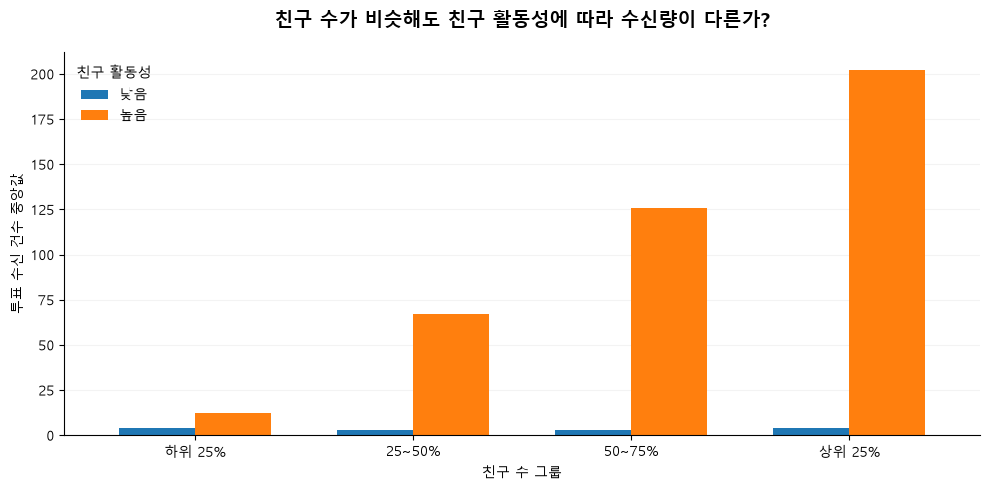

In [31]:
pivot_control = (
    df_control_summary
    .pivot(
        index="친구 수 그룹",
        columns="친구 활동성",
        values="수신_중앙값"
    )
)

ax = pivot_control.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.7
)

ax.set_title(
    "친구 수가 비슷해도 친구 활동성에 따라 수신량이 다른가?",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("친구 수 그룹")
ax.set_ylabel("투표 수신 건수 중앙값")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="친구 활동성",
    frameon=False
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### 5월 활동 → 6월 수신으로 시간 순서 분리

In [33]:
# 5월 / 6월 투표 데이터 분리
may_start = pd.Timestamp("2023-05-01")
june_start = pd.Timestamp("2023-06-01")
july_start = pd.Timestamp("2023-07-01")

df_vote_may = df_vote.loc[
    (df_vote["created_at"] >= may_start)
    & (df_vote["created_at"] < june_start)
].copy()

df_vote_june = df_vote.loc[
    (df_vote["created_at"] >= june_start)
    & (df_vote["created_at"] < july_start)
].copy()

print(f"5월 투표 기록: {len(df_vote_may):,}건")
print(f"6월 투표 기록: {len(df_vote_june):,}건")

print(
    "5월 투표 참여 사용자:",
    f"{df_vote_may['user_id'].nunique():,}명"
)

print(
    "6월 투표 수신 사용자:",
    f"{df_vote_june['chosen_user_id'].nunique():,}명"
)

5월 투표 기록: 718,718건
6월 투표 기록: 71,341건
5월 투표 참여 사용자: 4,196명
6월 투표 수신 사용자: 7,932명


##### 5월에 투표한 사용자 / 6월 수신량 생성

In [35]:
# 5월에 실제로 투표한 사용자
may_active_voters = set(
    df_vote_may["user_id"]
    .dropna()
    .astype("int64")
    .unique()
)

# 6월 사용자별 투표 수신 건수
df_june_receive = (
    df_vote_june
    .groupby("chosen_user_id")
    .size()
    .rename("june_receive_cnt")
    .reset_index()
    .rename(columns={"chosen_user_id": "user_id"})
)

df_june_receive["user_id"] = (
    df_june_receive["user_id"]
    .astype("int64")
)

# 이번 분석은 6월 실제 수신 기록이 존재하는 사용자 안에서
# '얼마나 많이 받았는가'를 비교
june_receiver_ids = set(
    df_june_receive["user_id"]
)

print(
    "6월 수신량 분석 대상:",
    f"{len(june_receiver_ids):,}명"
)

display(df_june_receive.head())

6월 수신량 분석 대상: 7,932명


,user_id,june_receive_cnt
0,833203,11
1,833294,3
2,833525,1
3,834112,1
4,837235,3


##### 5월 말 이전 친구 관계 추출

In [37]:
target_ids = june_receiver_ids

friend_parts = []

for chunk in pd.read_csv(
    friend_path,
    usecols=[
        "status",
        "send_user_id",
        "receive_user_id",
        "updated_at"
    ],
    chunksize=300_000
):
    accepted = chunk.loc[
        chunk["status"].eq("A")
    ].copy()

    if accepted.empty:
        continue

    accepted["updated_at"] = pd.to_datetime(
        accepted["updated_at"],
        errors="coerce"
    )

    # 5월 말 이전 A상태 관계 기록
    accepted = accepted.loc[
        accepted["updated_at"] < june_start
    ]

    if accepted.empty:
        continue

    for col in ["send_user_id", "receive_user_id"]:
        accepted[col] = pd.to_numeric(
            accepted[col],
            errors="coerce"
        )

    accepted = accepted.dropna(
        subset=["send_user_id", "receive_user_id"]
    )

    accepted["send_user_id"] = (
        accepted["send_user_id"].astype("int64")
    )

    accepted["receive_user_id"] = (
        accepted["receive_user_id"].astype("int64")
    )

    accepted = accepted.loc[
        accepted["send_user_id"].isin(target_ids)
        | accepted["receive_user_id"].isin(target_ids)
    ]

    if accepted.empty:
        continue

    sender = (
        accepted[
            ["send_user_id", "receive_user_id"]
        ]
        .rename(columns={
            "send_user_id": "user_id",
            "receive_user_id": "friend_id"
        })
    )

    receiver = (
        accepted[
            ["receive_user_id", "send_user_id"]
        ]
        .rename(columns={
            "receive_user_id": "user_id",
            "send_user_id": "friend_id"
        })
    )

    pairs = pd.concat(
        [sender, receiver],
        ignore_index=True
    )

    pairs = pairs.loc[
        pairs["user_id"].isin(target_ids)
    ]

    friend_parts.append(pairs)

df_may_friend_pairs = (
    pd.concat(friend_parts, ignore_index=True)
    .drop_duplicates(["user_id", "friend_id"])
)

df_may_friend_pairs = df_may_friend_pairs.loc[
    df_may_friend_pairs["user_id"]
    != df_may_friend_pairs["friend_id"]
].copy()

print(
    "5월 말 이전 친구 관계:",
    f"{len(df_may_friend_pairs):,}쌍"
)

5월 말 이전 친구 관계: 167,127쌍


##### 5월 활동 친구 비율 계산

In [38]:
# 친구가 5월에 투표한 기록이 있는지
df_may_friend_pairs["active_friend_may"] = (
    df_may_friend_pairs["friend_id"]
    .isin(may_active_voters)
)

df_may_friend_summary = (
    df_may_friend_pairs
    .groupby("user_id")
    .agg(
        friend_cnt=("friend_id", "nunique"),
        active_friend_cnt_may=("active_friend_may", "sum")
    )
    .reset_index()
)

df_may_friend_summary["active_friend_ratio_may"] = (
    df_may_friend_summary["active_friend_cnt_may"]
    / df_may_friend_summary["friend_cnt"]
)

# 6월 수신량 결합
df_lag = (
    df_june_receive
    .merge(
        df_may_friend_summary,
        on="user_id",
        how="inner"
    )
)

print(f"최종 시간순서 분석 대상: {len(df_lag):,}명")

display(df_lag.head())

최종 시간순서 분석 대상: 6,091명


,user_id,june_receive_cnt,friend_cnt,active_friend_cnt_may,active_friend_ratio_may
0,833203,11,6,0,0.0
1,833294,3,1,0,0.0
2,833525,1,5,1,0.2
3,837530,14,1,0,0.0
4,837557,1,8,0,0.0


##### 활동 친구 비율 기준 동일 인원 4등분

In [47]:
# 5월 활동 친구 비율 기준 순위
df_lag["activity_rank"] = (
    df_lag["active_friend_ratio_may"]
    .rank(method="first")
)

# 사용자 수가 최대한 동일하도록 4등분
df_lag["5월 활동 친구 비율 그룹"] = pd.qcut(
    df_lag["activity_rank"],
    q=4,
    labels=[
        "하위 25%",
        "25~50%",
        "50~75%",
        "상위 25%"
    ]
)

# 그룹별 요약
df_lag_summary = (
    df_lag
    .groupby(
        "5월 활동 친구 비율 그룹",
        observed=True
    )
    .agg(
        사용자_수=("user_id", "nunique"),
        활동친구비율_중앙값=("active_friend_ratio_may", "median"),
        활동친구비율_평균=("active_friend_ratio_may", "mean"),
        친구수_중앙값=("friend_cnt", "median"),
        june_receive_median=("june_receive_cnt", "median"),
        june_receive_mean=("june_receive_cnt", "mean")
    )
    .reset_index()
)

# 비율을 % 단위로 변환
df_lag_summary["활동친구비율_중앙값"] = (
    df_lag_summary["활동친구비율_중앙값"] * 100
).round(1)

df_lag_summary["활동친구비율_평균"] = (
    df_lag_summary["활동친구비율_평균"] * 100
).round(1)

df_lag_summary["june_receive_mean"] = (
    df_lag_summary["june_receive_mean"].round(1)
)

# 보기 좋은 컬럼명으로 변경
df_lag_summary = df_lag_summary.rename(columns={
    "june_receive_median": "6월 수신 중앙값",
    "june_receive_mean": "6월 수신 평균"
})

display(df_lag_summary)

,5월 활동 친구 비율 그룹,사용자_수,활동친구비율_중앙값,활동친구비율_평균,친구수_중앙값,6월 수신 중앙값,6월 수신 평균
0,하위 25%,1523,0.0,0.1,5.0,2.0,3.1
1,25~50%,1523,10.3,14.6,28.0,2.0,4.8
2,50~75%,1522,80.0,76.2,24.0,9.0,16.7
3,상위 25%,1523,100.0,98.5,21.0,8.0,15.8


##### 시간 순서 결과 시각화

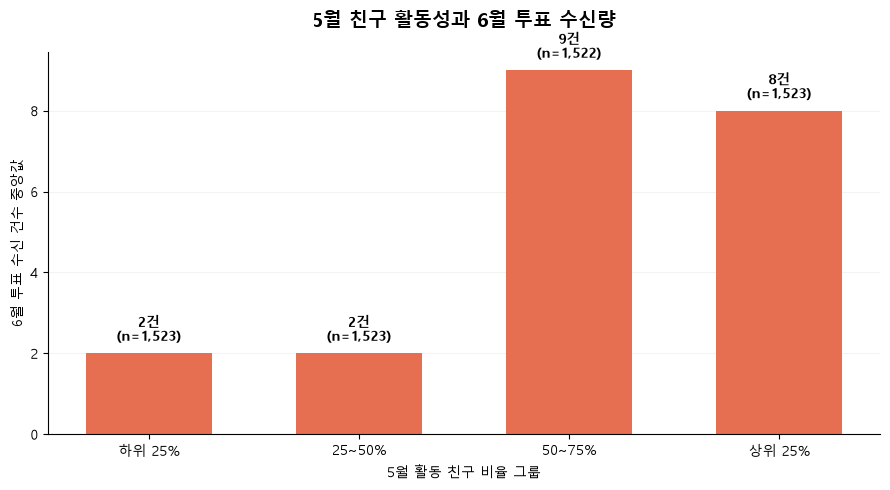

In [50]:
fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df_lag_summary[
        "5월 활동 친구 비율 그룹"
    ].astype(str),
    df_lag_summary["6월 수신 중앙값"],
    color="#E76F51",
    width=0.6
)

for bar, value, n in zip(
    bars,
    df_lag_summary["6월 수신 중앙값"],
    df_lag_summary["사용자_수"]
):
    ax.annotate(
        f"{value:.0f}건\n(n={n:,})",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 7),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.set_xlabel("5월 활동 친구 비율 그룹")
ax.set_ylabel("6월 투표 수신 건수 중앙값")

ax.set_title(
    "5월 친구 활동성과 6월 투표 수신량",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### 사용자별 학급 규모 계산

In [52]:
# 사용자별 학급 정보 준비
df_user_group = (
    df_user[["id", "group_id"]]
    .drop_duplicates(subset="id")
    .copy()
)

# ID 타입 통일
df_user_group["id"] = pd.to_numeric(
    df_user_group["id"],
    errors="coerce"
).astype("Int64")

df_lag["user_id"] = pd.to_numeric(
    df_lag["user_id"],
    errors="coerce"
).astype("Int64")


# group_id별 사용자 수 = 학급 규모
group_size_map = (
    df_user_group
    .dropna(subset=["group_id"])
    .groupby("group_id")["id"]
    .nunique()
)


# 각 사용자에게 학급 규모 부여
df_user_group["group_size"] = (
    df_user_group["group_id"]
    .map(group_size_map)
)


# merge 재실행 시 생길 수 있는 기존 컬럼 제거
drop_cols = [
    col for col in [
        "group_id",
        "group_id_x",
        "group_id_y",
        "group_size"
    ]
    if col in df_lag.columns
]

df_lag = df_lag.drop(columns=drop_cols)


# 사용자별 학급 정보 결합
df_lag = df_lag.merge(
    df_user_group[
        ["id", "group_id", "group_size"]
    ].rename(columns={"id": "user_id"}),
    on="user_id",
    how="left",
    validate="m:1"
)


print(
    "학급 규모 확인 가능:",
    f"{df_lag['group_size'].notna().sum():,}명"
)

display(
    df_lag[
        [
            "user_id",
            "friend_cnt",
            "active_friend_ratio_may",
            "group_id",
            "group_size",
            "june_receive_cnt"
        ]
    ].head()
)

학급 규모 확인 가능: 6,091명


,user_id,friend_cnt,active_friend_ratio_may,group_id,group_size,june_receive_cnt
0,833203,6,0.0,42.0,18,11
1,833294,1,0.0,60.0,14,3
2,833525,5,0.2,39.0,16,1
3,837530,1,0.0,155.0,15,14
4,837557,8,0.0,153.0,15,1


##### 학급 규모도 동일 인원 4등분

In [53]:
df_lag_group = (
    df_lag
    .dropna(subset=["group_size"])
    .copy()
)

df_lag_group["group_rank"] = (
    df_lag_group["group_size"]
    .rank(method="first")
)

df_lag_group["학급 규모 그룹"] = pd.qcut(
    df_lag_group["group_rank"],
    q=4,
    labels=[
        "하위 25%",
        "25~50%",
        "50~75%",
        "상위 25%"
    ]
)

##### 같은 학급 규모 안에서 활동 친구 효과 비교

In [54]:
# 각 학급 규모 그룹 안에서
# 활동 친구 비율 기준 절반으로 나눔
df_lag_group["activity_rank_within_group"] = (
    df_lag_group
    .groupby(
        "학급 규모 그룹",
        observed=True
    )["active_friend_ratio_may"]
    .rank(
        method="first",
        pct=True
    )
)

df_lag_group["친구 활동성"] = np.where(
    df_lag_group["activity_rank_within_group"] <= 0.5,
    "낮음",
    "높음"
)

# 그룹별 요약
df_group_control = (
    df_lag_group
    .groupby(
        ["학급 규모 그룹", "친구 활동성"],
        observed=True
    )
    .agg(
        사용자_수=("user_id", "nunique"),
        학급규모_중앙값=("group_size", "median"),
        친구수_중앙값=("friend_cnt", "median"),
        활동친구비율_중앙값=("active_friend_ratio_may", "median"),
        june_receive_median=("june_receive_cnt", "median"),
        june_receive_mean=("june_receive_cnt", "mean")
    )
    .reset_index()
)

# 활동 친구 비율을 %로 변환
df_group_control["활동친구비율_중앙값"] = (
    df_group_control["활동친구비율_중앙값"] * 100
).round(1)

# 평균 반올림
df_group_control["june_receive_mean"] = (
    df_group_control["june_receive_mean"]
    .round(1)
)

# 보기 좋은 컬럼명으로 변경
df_group_control = df_group_control.rename(columns={
    "june_receive_median": "6월 수신 중앙값",
    "june_receive_mean": "6월 수신 평균"
})

display(df_group_control)

,학급 규모 그룹,친구 활동성,사용자_수,학급규모_중앙값,친구수_중앙값,활동친구비율_중앙값,6월 수신 중앙값,6월 수신 평균
0,하위 25%,낮음,761,9.0,14.0,0.0,2.0,3.2
1,하위 25%,높음,762,10.0,19.0,76.2,6.0,13.6
2,25~50%,낮음,761,14.0,15.0,0.0,2.0,3.5
3,25~50%,높음,762,14.0,23.0,89.8,6.0,12.1
4,50~75%,낮음,761,17.0,21.0,4.8,2.0,5.0
5,50~75%,높음,761,18.0,27.0,94.2,9.0,17.5
6,상위 25%,낮음,761,22.0,12.0,11.1,3.0,7.5
7,상위 25%,높음,762,22.0,22.0,97.9,11.0,18.4


##### 학급 규모 통제 결과 시각화

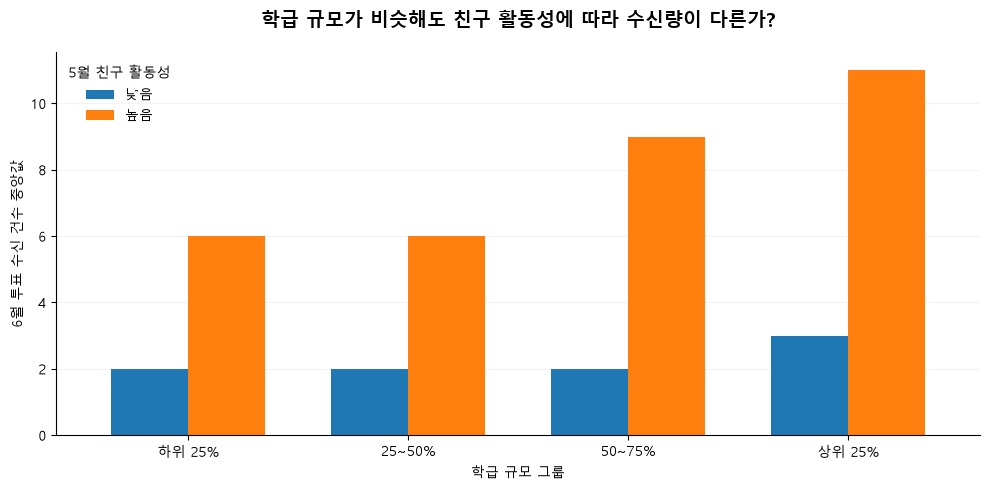

In [56]:
pivot_group = (
    df_group_control
    .pivot(
        index="학급 규모 그룹",
        columns="친구 활동성",
        values="6월 수신 중앙값"
    )
)

ax = pivot_group.plot(
    kind="bar",
    figsize=(10, 5),
    width=0.7
)

ax.set_title(
    "학급 규모가 비슷해도 친구 활동성에 따라 수신량이 다른가?",
    fontsize=14,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("학급 규모 그룹")
ax.set_ylabel("6월 투표 수신 건수 중앙값")

ax.tick_params(
    axis="x",
    rotation=0
)

ax.legend(
    title="5월 친구 활동성",
    frameon=False
)

ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

##### Spearman 순위 상관 비교

In [57]:
corr_cols = [
    "friend_cnt",
    "active_friend_cnt_may",
    "active_friend_ratio_may",
    "june_receive_cnt"
]

corr = (
    df_lag[corr_cols]
    .corr(method="spearman")
)

display(
    corr[["june_receive_cnt"]]
    .rename(columns={
        "june_receive_cnt": "6월 수신량과의 Spearman 상관"
    })
    .round(3)
)

,6월 수신량과의 Spearman 상관
friend_cnt,0.139
active_friend_cnt_may,0.488
active_friend_ratio_may,0.491
june_receive_cnt,1.000


### 구간 문제 정리 시각화 자료 추출

#### 공통 설정

In [58]:
import matplotlib.pyplot as plt
import numpy as np
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

#### 친구 관련 지표와 이후 수신량의 관계

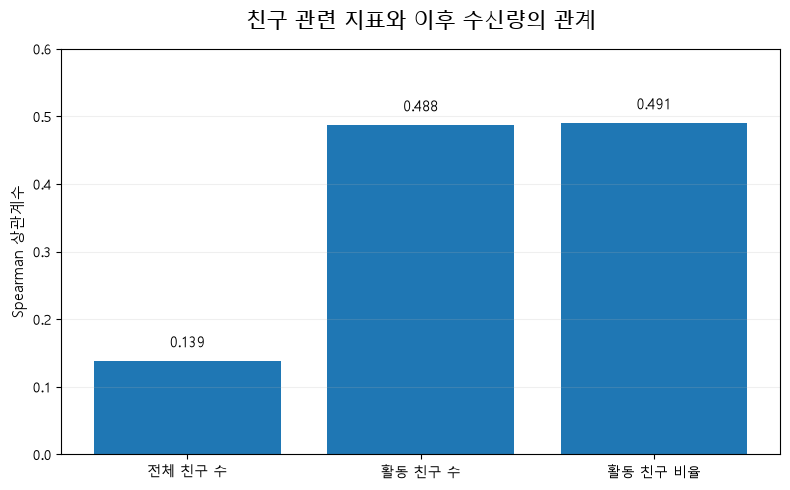

In [59]:
# 데이터
labels = ['전체 친구 수', '활동 친구 수', '활동 친구 비율']
values = [0.139, 0.488, 0.491]

# 그래프
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(labels, values)

ax.set_title('친구 관련 지표와 이후 수신량의 관계', fontsize=15, pad=15)
ax.set_ylabel('Spearman 상관계수', fontsize=11)
ax.set_ylim(0, 0.6)

# 막대 위 값 표시
for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f'{value:.3f}',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

#### 학급 규모별 활동 친구 수준과 이후 수신량

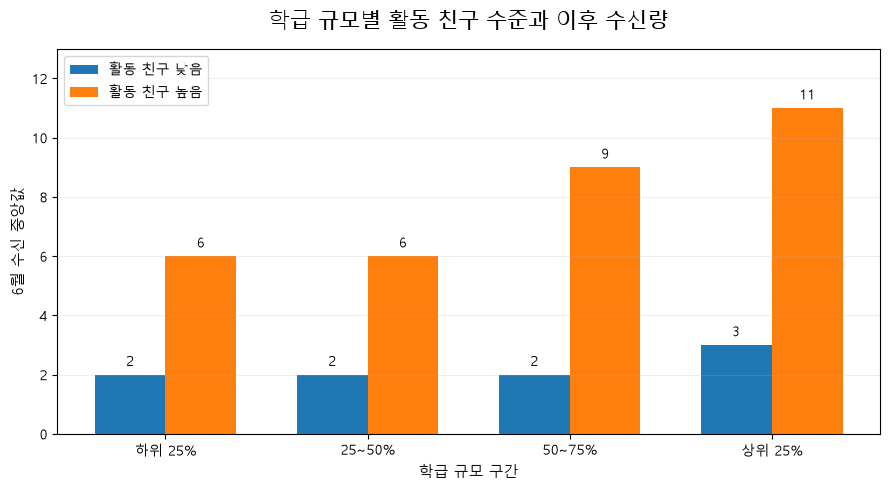

In [60]:
# 데이터
class_size = ['하위 25%', '25~50%', '50~75%', '상위 25%']

low_active = [2, 2, 2, 3]
high_active = [6, 6, 9, 11]

x = np.arange(len(class_size))
width = 0.35

# 그래프
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width/2,
    low_active,
    width,
    label='활동 친구 낮음'
)

bars2 = ax.bar(
    x + width/2,
    high_active,
    width,
    label='활동 친구 높음'
)

ax.set_title('학급 규모별 활동 친구 수준과 이후 수신량', fontsize=15, pad=15)
ax.set_xlabel('학급 규모 구간', fontsize=11)
ax.set_ylabel('6월 수신 중앙값', fontsize=11)

ax.set_xticks(x)
ax.set_xticklabels(class_size)

ax.legend()

# 값 표시
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.2,
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10
        )

ax.set_ylim(0, 13)
ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

#### 초기 수신량별 이후 투표 시작률

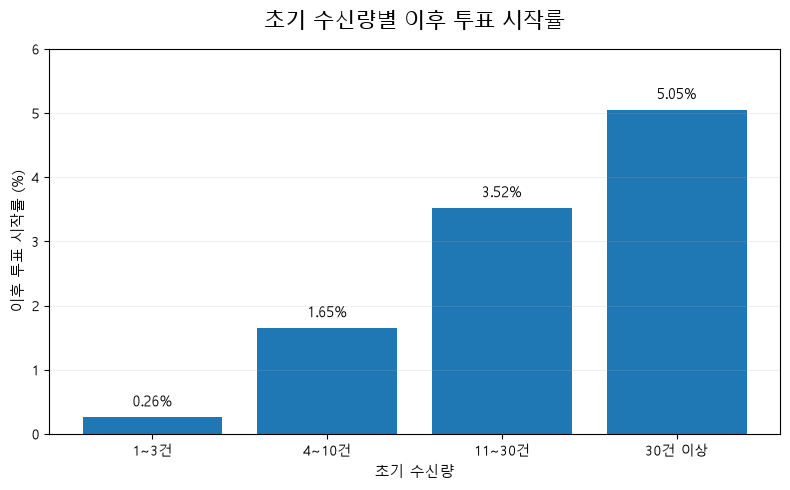

In [61]:
# 데이터
receipt_group = ['1~3건', '4~10건', '11~30건', '30건 이상']
vote_start_rate = [0.26, 1.65, 3.52, 5.05]

# 그래프
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(receipt_group, vote_start_rate)

ax.set_title('초기 수신량별 이후 투표 시작률', fontsize=15, pad=15)
ax.set_xlabel('초기 수신량', fontsize=11)
ax.set_ylabel('이후 투표 시작률 (%)', fontsize=11)

ax.set_ylim(0, 6)

# 값 표시
for bar, value in zip(bars, vote_start_rate):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.12,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontsize=11
    )

ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()